In [ ]:
from utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

DATA_DIR += 'Centrality/'
graph_path = DATA_DIR + 'Centrality_climate_19.graphml'
VISUAL_DIR += 'Centrality/'
G = load_graph(graph_path)

/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


In [40]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

# CCDF (Complementary cumulative distribution)

In [ ]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True, savefile='', title=''):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = cmap(0), label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    if title:
        ax.set_title(title)
    else:
        ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()

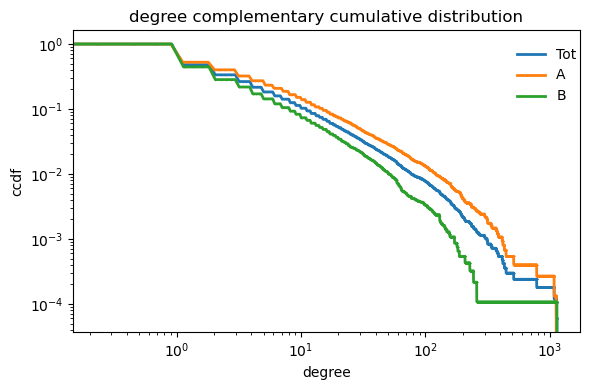

In [42]:
plot_ccdf(G, 'degree', log=True)

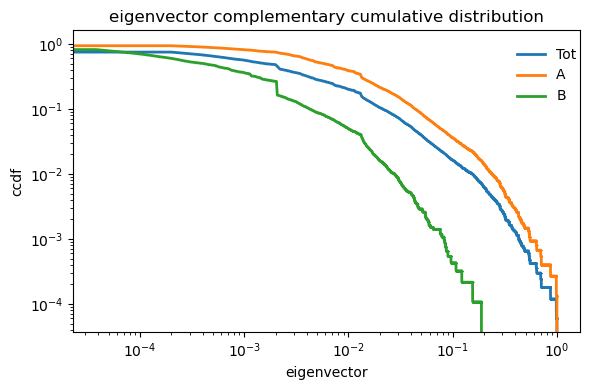

In [43]:
plot_ccdf(G, 'eigenvector', log=True)

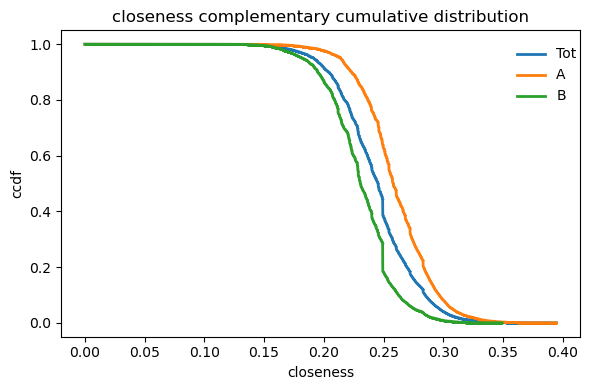

In [44]:
plot_ccdf(G, 'closeness', log=False)

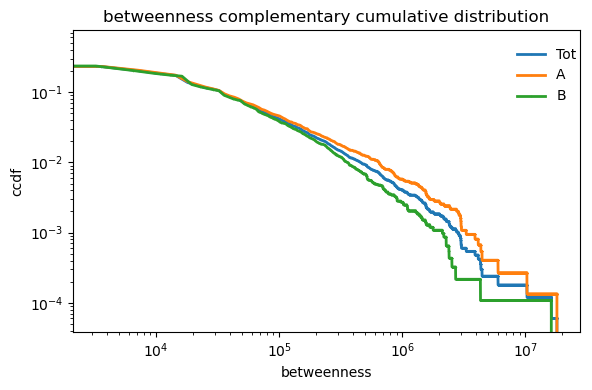

In [45]:
plot_ccdf(G, 'betweenness', log=True)

# Distribution Fit

In [ ]:
def interpol(G: ig.Graph, metric: str='degree', log: bool=True):
    FIT_INTERVAL = (0,250)
    vals, ccdf = compute_ccdf(np.array(G.vs[metric]))
    in_vals_m = (vals > FIT_INTERVAL[0]) & (vals < FIT_INTERVAL[1])
    in_vals = np.log10(vals[in_vals_m])
    in_ccdf = np.log10(ccdf[in_vals_m])
    slope, intercept, R, p, err = linregress(in_vals, in_ccdf)

    # Ottieni l'esponente alpha
    print(f"Esponente alpha: {slope}")
    # Stampa i parametri di controllo
    print(f"R: {R}, p-value: {p}")

    # Ordinate per la curva teorica
    y_theory = intercept + slope * np.log10(vals)

    plt.figure(figsize=(8, 6))

    # Curva teorica
    plt.plot(np.log10(vals), y_theory, 'r-', linewidth=2, label=f'Fit power law (α={slope:.2f})')

    # CCDF empirica completa
    plt.plot(np.log10(vals), np.log10(ccdf), 'b-', linewidth=2, label='CCDF empirica')

    plt.xlim(0,3.5)

    plt.xlabel('Grado')
    plt.ylabel('P(Grado ≥ x)')
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.show()
    
def scatter_centrality(G: ig.Graph, metric: str='degree', log: bool=True):
    values = np.array(G.vs[metric])
    values_count = np.unique_counts(values)
    P_x = values_count.counts / len(values)
    
    # kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    # kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
    ax.scatter(values_count.values, P_x, color = cmap(0), label='Tot', alpha=0.8)
    # ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    # ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    # fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    return {'values': values_count.values, 'probability': P_x, 'ax': ax}

# Scatter plot

In [46]:
def scatter_betweenness_degree(G: ig.Graph, savefile='', title=''):
        fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
        ax.scatter(G.vs['degree'], G.vs['betweenness'], s=0.3, color=cmap(0))
        if title:
                ax.set_title(title)
        else:
                ax.set_title('betweenness vs degree')
        ax.set_title('betweenness vs degree')
        ax.set_xlabel('degree')
        ax.set_ylabel('betweenness')
        ax.set_xscale('log')
        ax.set_yscale('log')
        if savefile:
                plt.savefig(savefile)
        else:
                plt.show()

# Distribuzioni di misure di centralità

Domanda:
sono gli stessi nodi a generare i picchi nei vari grafici?

In [48]:
def plot_centralities(G: ig.Graph, savefile='', title=''):
        metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        for ax, m in zip(axes.flat, metrics):
                values = np.array(G.vs[m], dtype=float)

                valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
                valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
                valuesA = valuesA[valuesA > 0]
                valuesB = valuesB[valuesB > 0]

                ax.hist(np.log10(valuesA), bins=40, density=True,
                        color=cmap(0), alpha=0.5, edgecolor='white', label='A')
                ax.hist(np.log10(valuesB), bins=40, density=True,
                        color=cmap(3), alpha=0.5, edgecolor='white', label='B')
                ax.set_title(m.capitalize())
                ax.set_xlabel(m)
                ax.set_ylabel("Densità di probabilità" if ax == axes[0, 0] else "")
                ax.grid(alpha=0.3)
                ax.legend()
        if title:
                fig.suptitle(title)
        else:
                fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
        plt.tight_layout()
        if savefile:
                plt.savefig(savefile)
        else:
                plt.show()

# Spearman rank

In [49]:
from scipy.stats import spearmanr

metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
df = pd.DataFrame({m: G.vs[m] for m in metrics})

# --- Matrice di correlazione di Spearman ---
corr_matrix, p_matrix = spearmanr(df)
corr_df = pd.DataFrame(corr_matrix, index=metrics, columns=metrics)

print(corr_df.round(3))

             degree  eigenvector  closeness  betweenness
degree        1.000        0.549      0.596        0.943
eigenvector   0.549        1.000      0.979        0.470
closeness     0.596        0.979      1.000        0.522
betweenness   0.943        0.470      0.522        1.000


In [50]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors
# G.vs['coreness'] = G.coreness()

def plot_spearMatrix(G: ig.Graph, savefile='', title=''):
    # --- 2. Calcola le centralità ---
    centralities = {
        'degree':      G.vs['degree'],
        'closeness':   G.vs['closeness'],
        'betweenness': G.vs['betweenness'],
        'coreness':    G.vs['coreness'],
    }

    labels = list(centralities.keys())
    n = len(labels)
    data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

    # --- 3. Matrice di correlazione di Spearman ---
    corr_matrix = np.ones((n, n))
    pval_matrix = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            r, p = spearmanr(data[i], data[j])
            corr_matrix[i, j] = r
            corr_matrix[j, i] = r
            pval_matrix[i, j] = p
            pval_matrix[j, i] = p

    # --- 4. Plot heatmap con matplotlib puro ---
    fig, ax = plt.subplots(figsize=(5, 5))
    if title:
        ax.set_title(title)

    # Colormap divergente centrata su 0
    cmap_heat = 'Blues'
    vmin, vmax = -1, 1
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax.imshow(corr_matrix, cmap=cmap_heat, norm=norm, aspect='auto')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman ρ", fontsize=11)

    # Etichette assi
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)

    low = corr_matrix.min() if vmin is None else vmin
    high = corr_matrix.max() if vmax is None else vmax
    threshold = (low + high) / 2.0 if high > low else high
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            value = corr_matrix[i, j]
            text_color = 'white' if value >= threshold else 'black'
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha='center',
                va='center',
                color=text_color,
            )
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()

# Plot Complessivi

/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)
/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)
/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)
/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)
/home/lore/PyProjects/Networks/AVRC_FinnishT

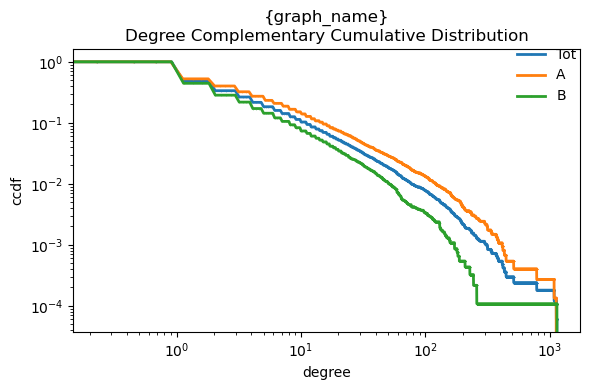

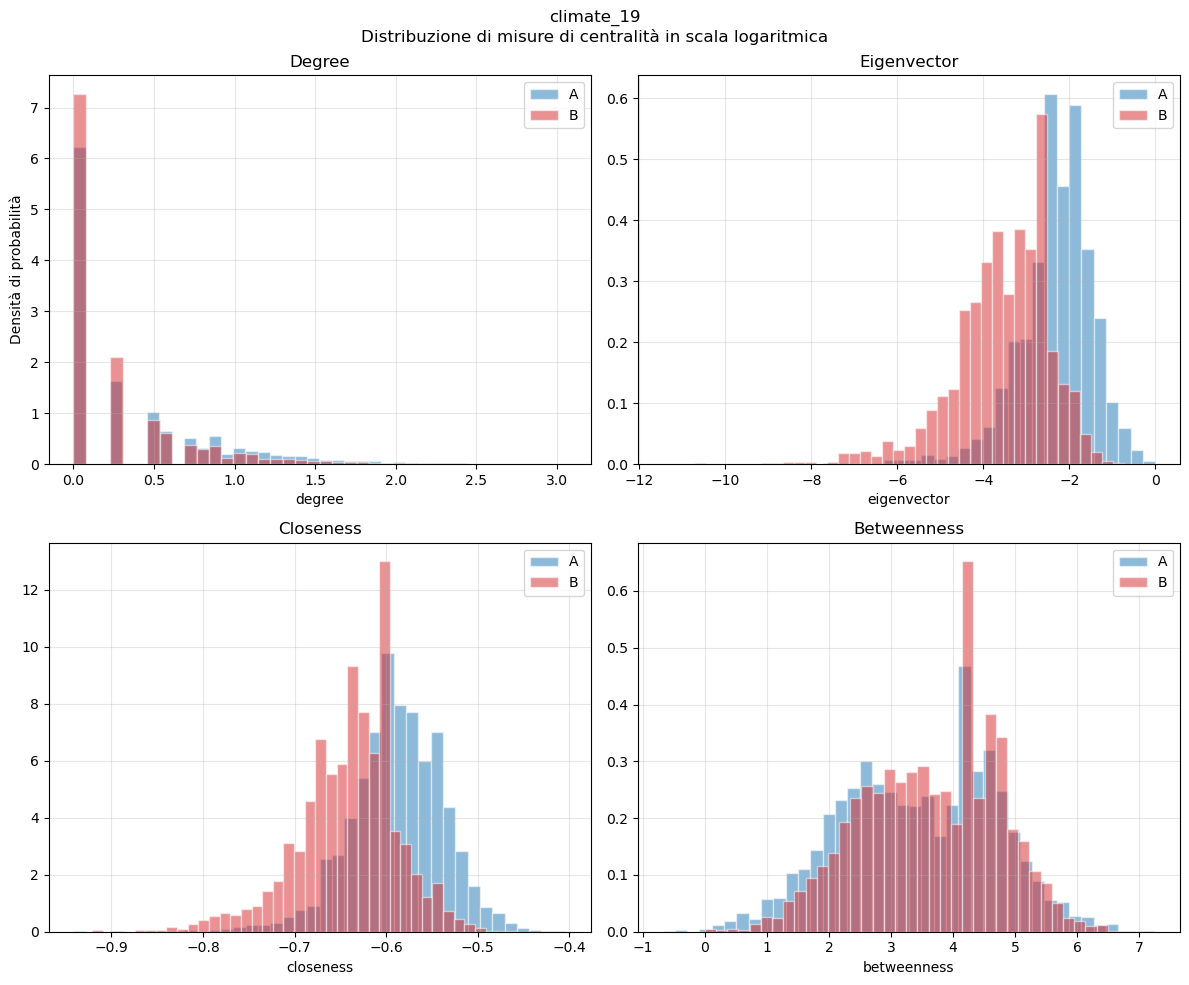

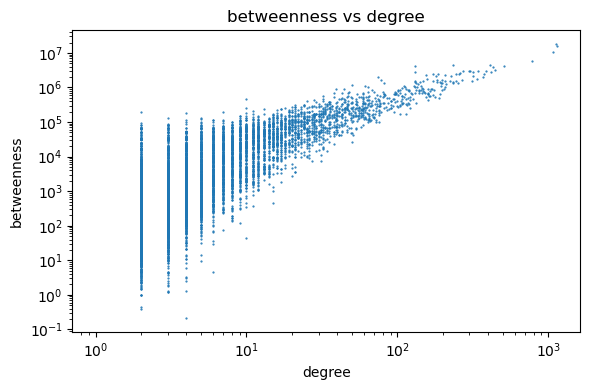

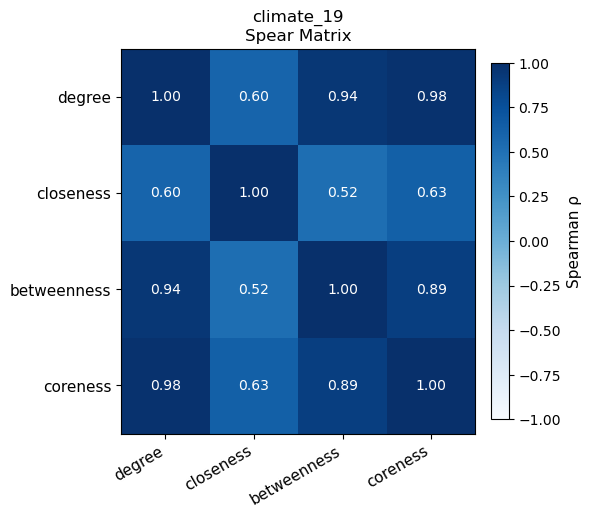

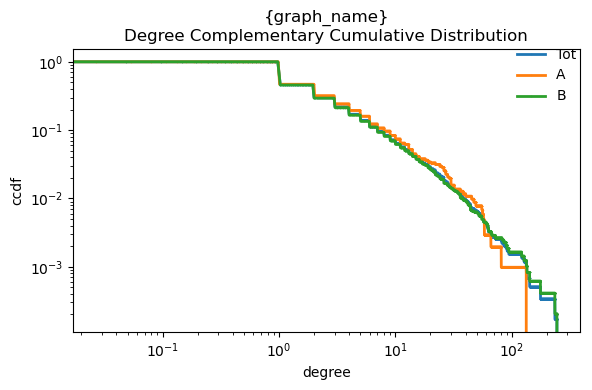

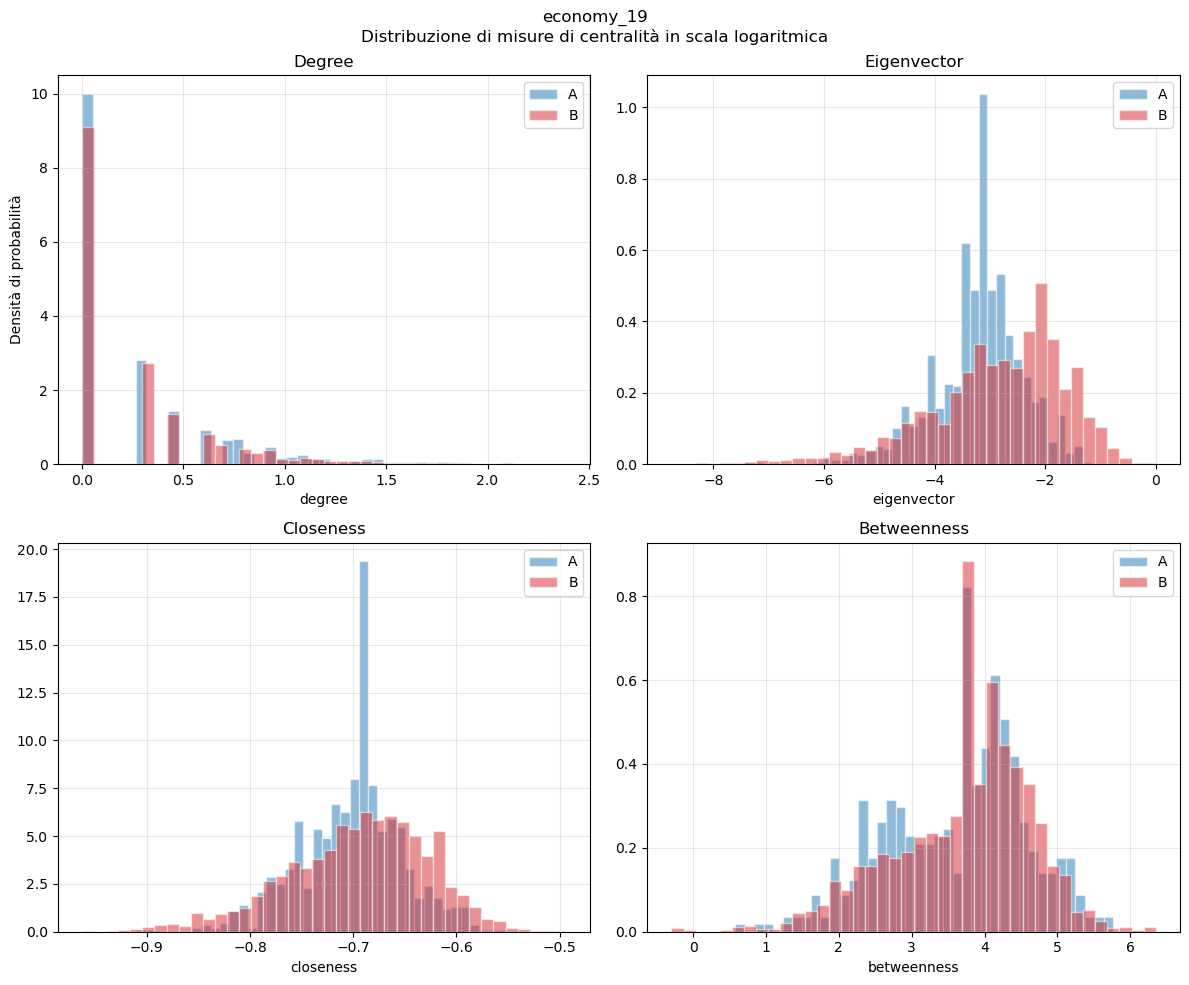

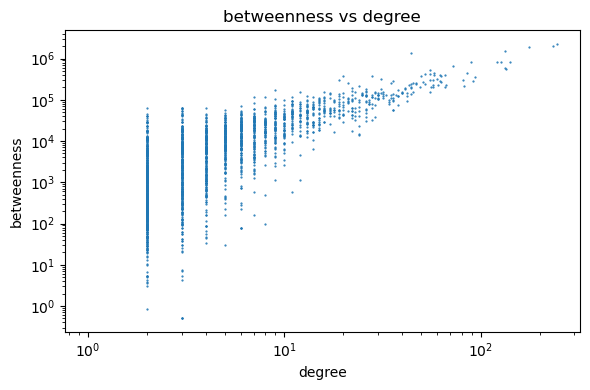

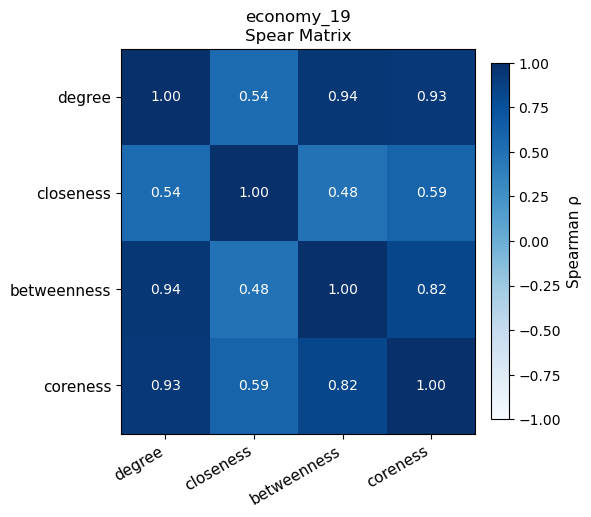

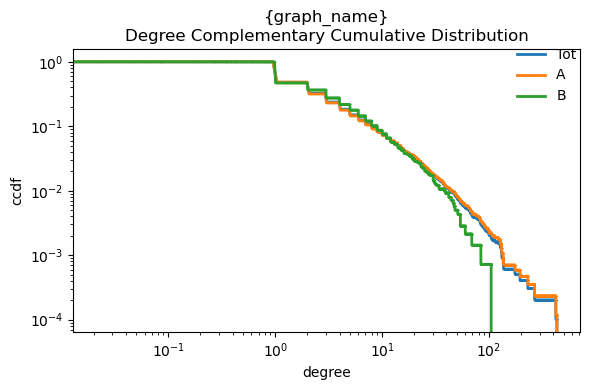

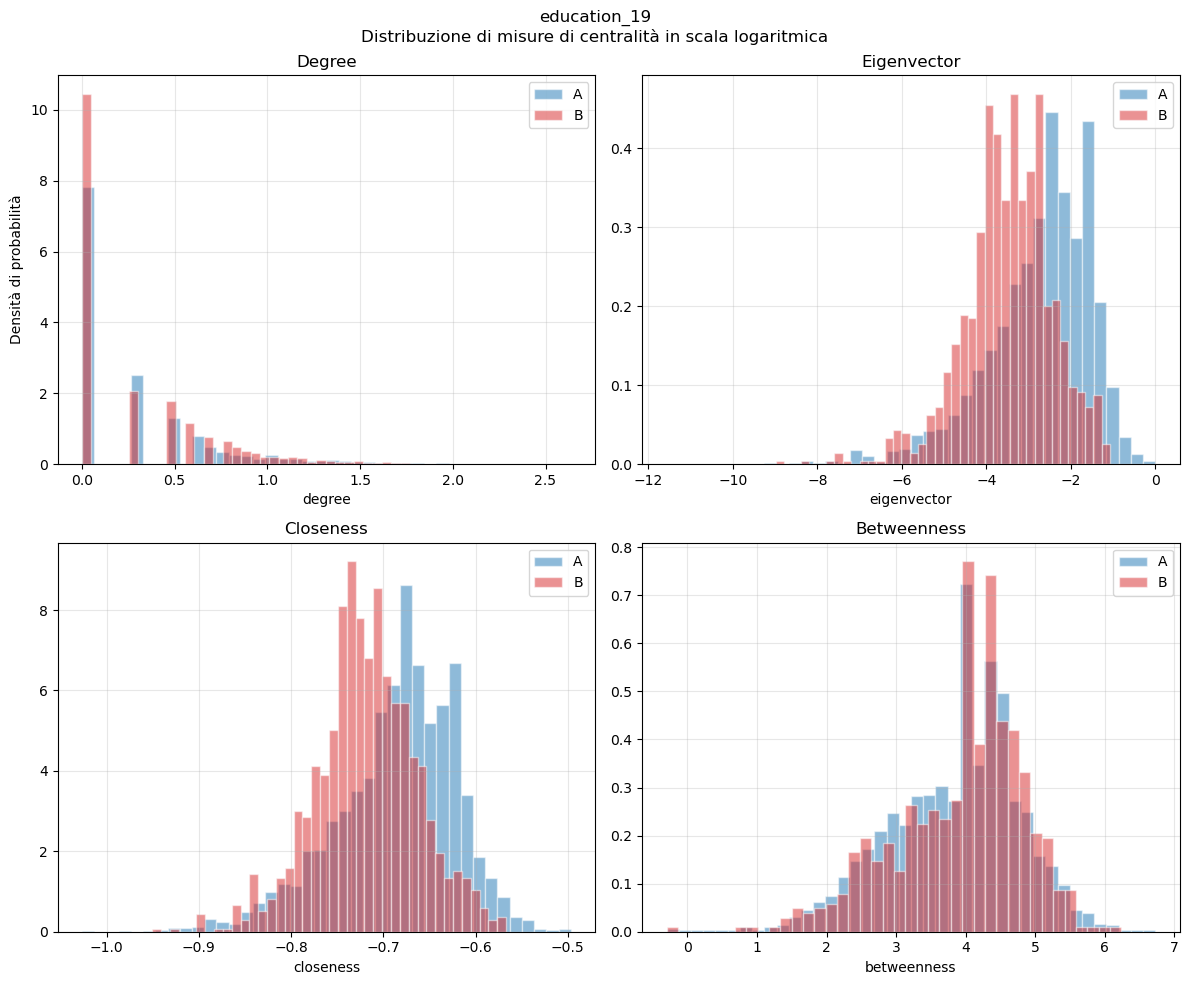

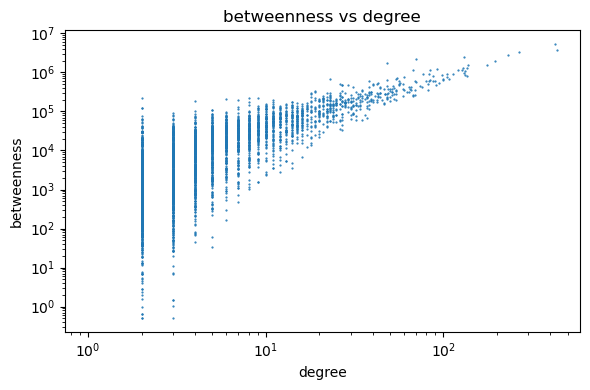

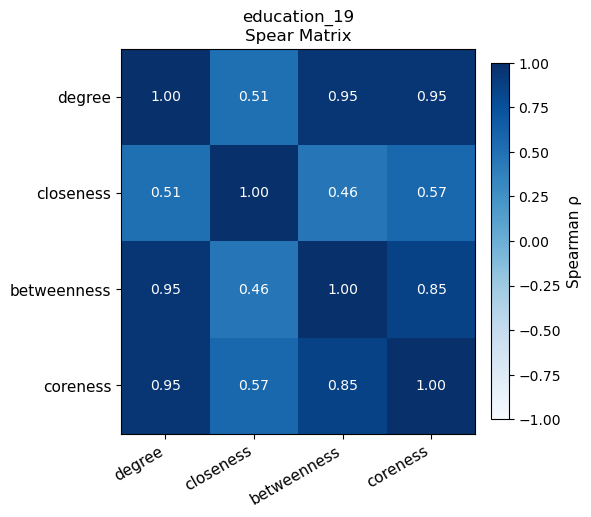

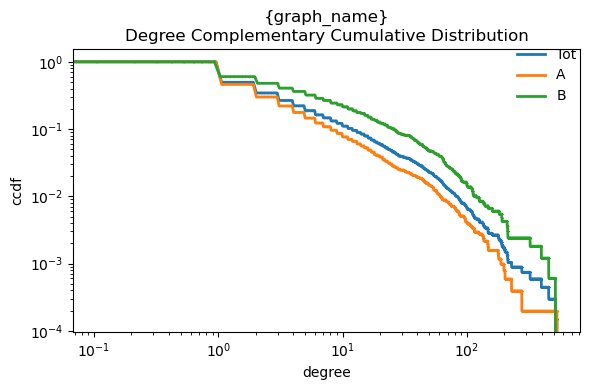

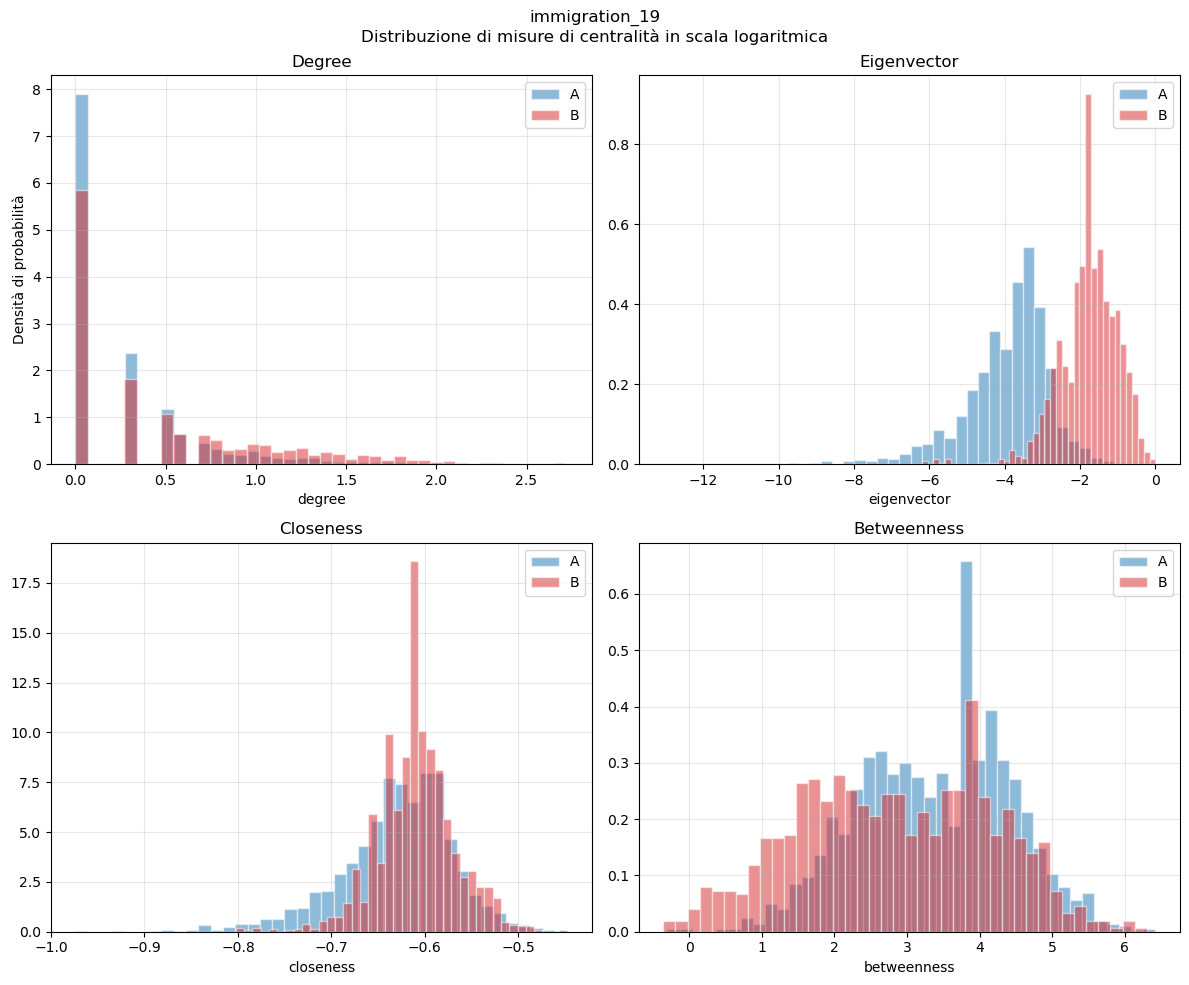

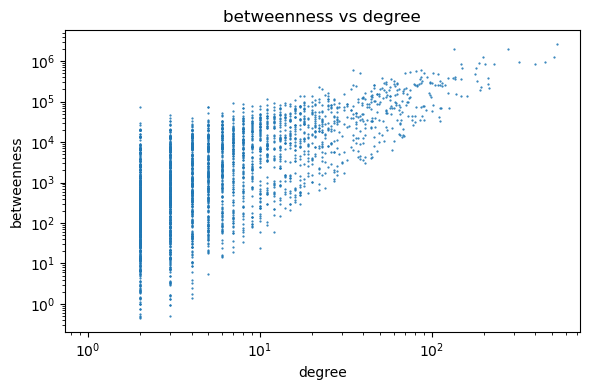

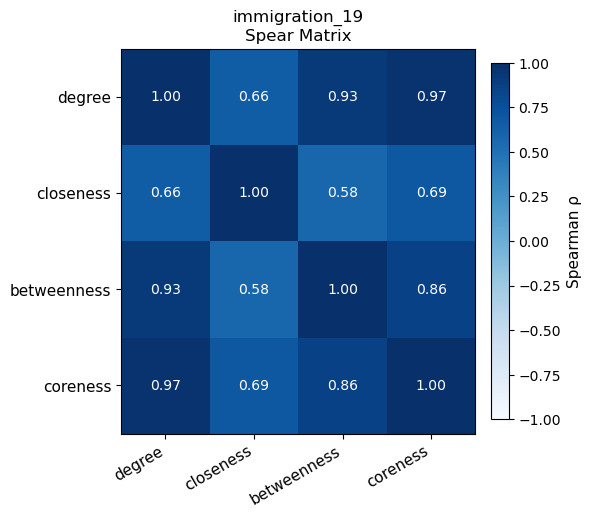

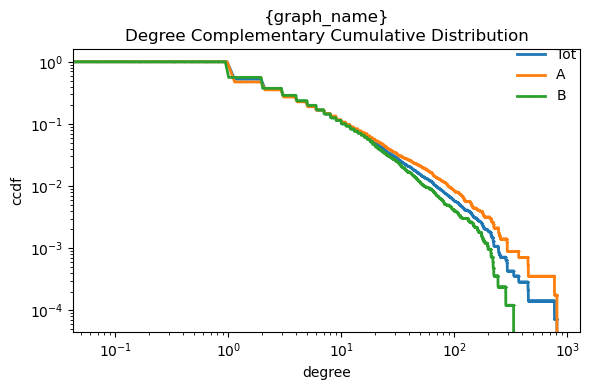

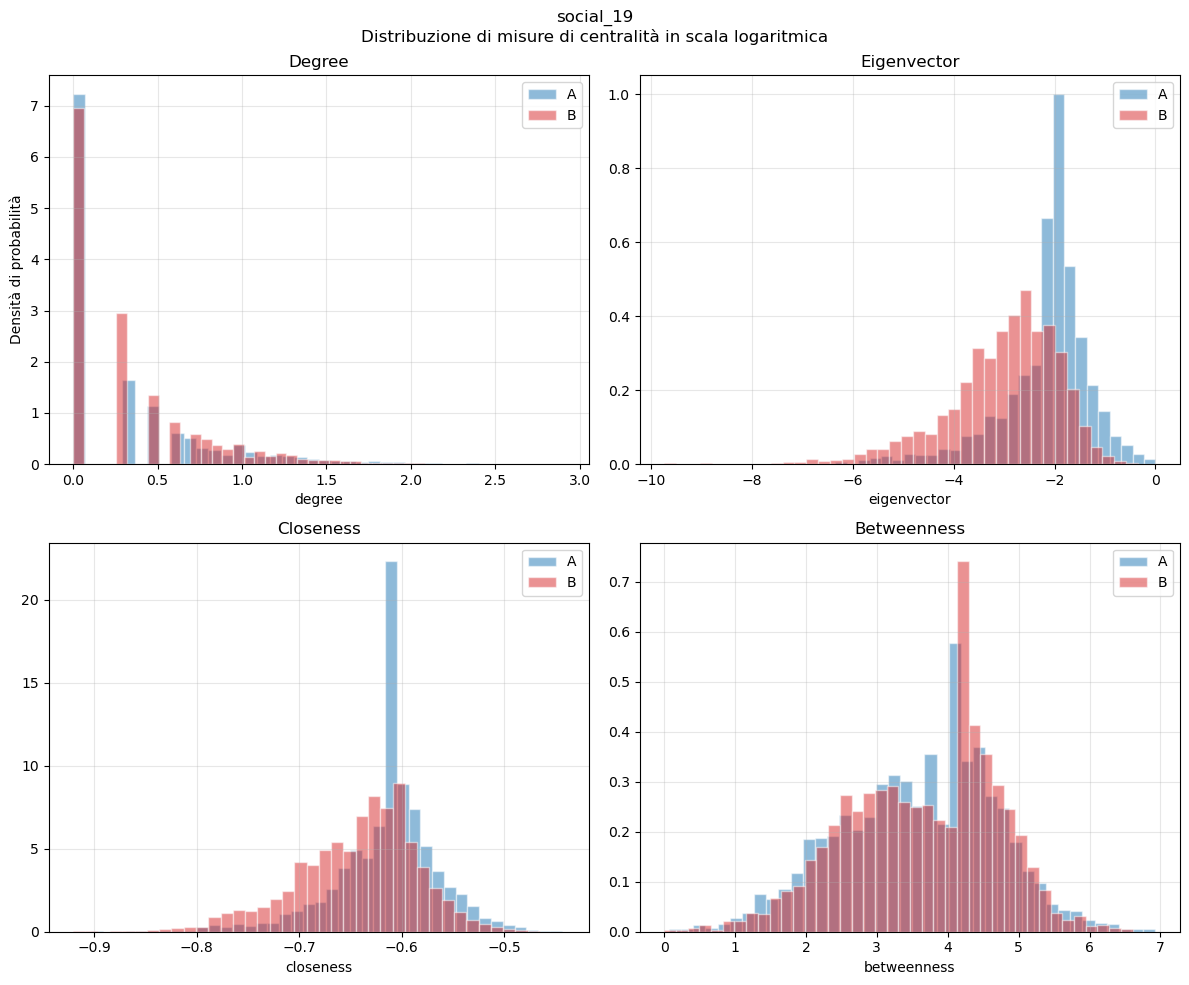

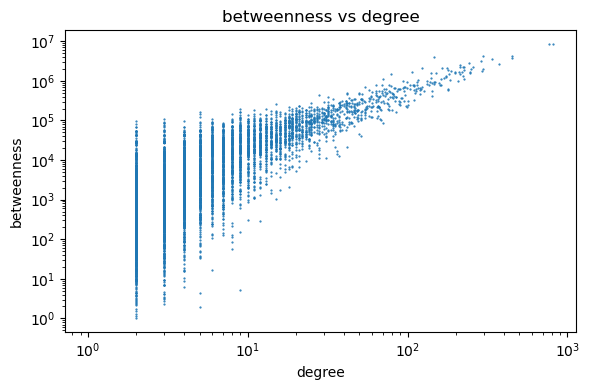

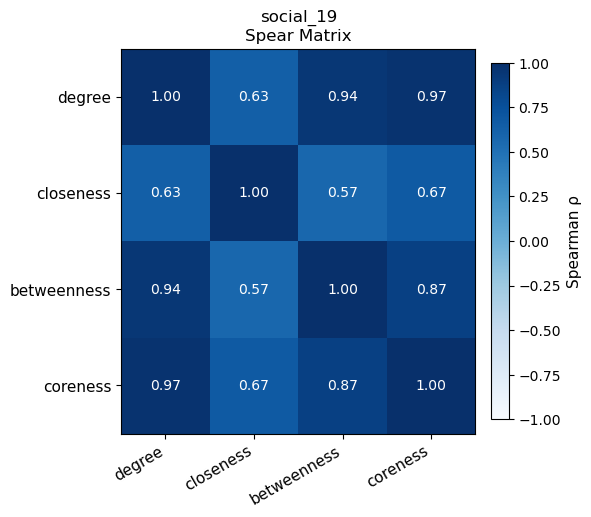

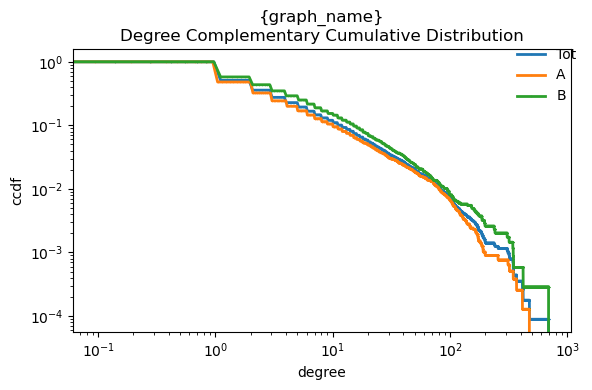

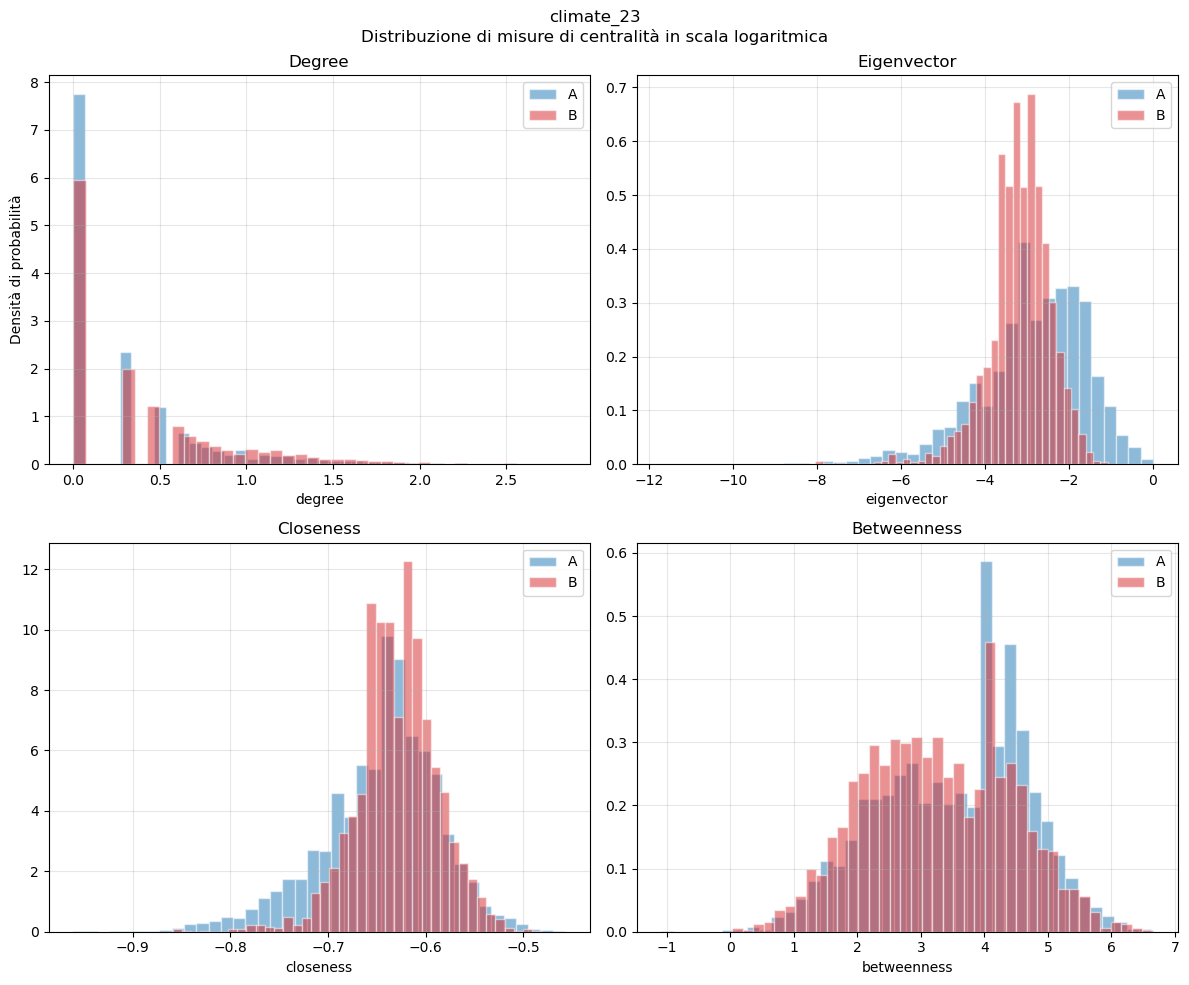

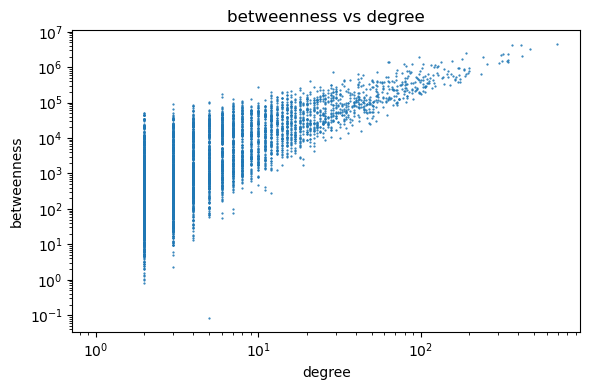

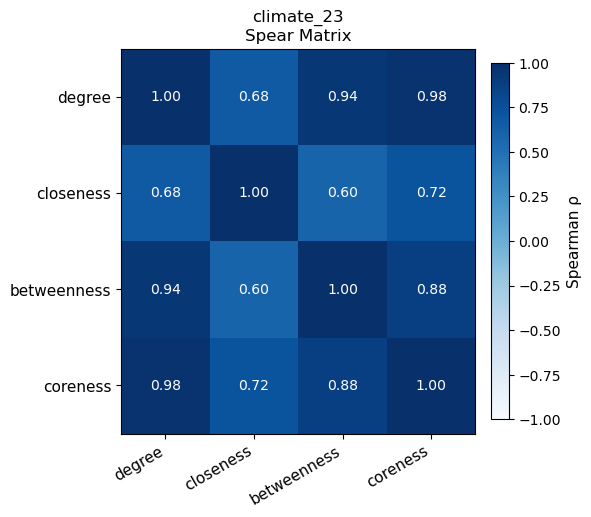

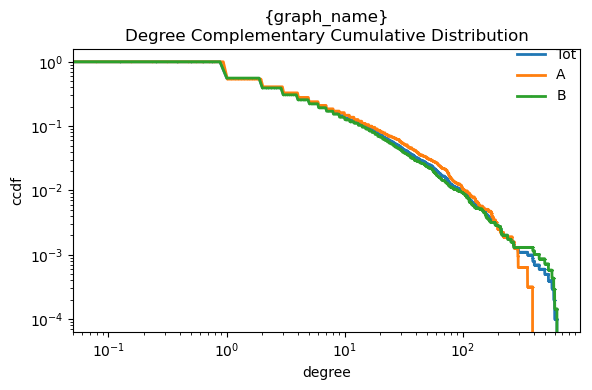

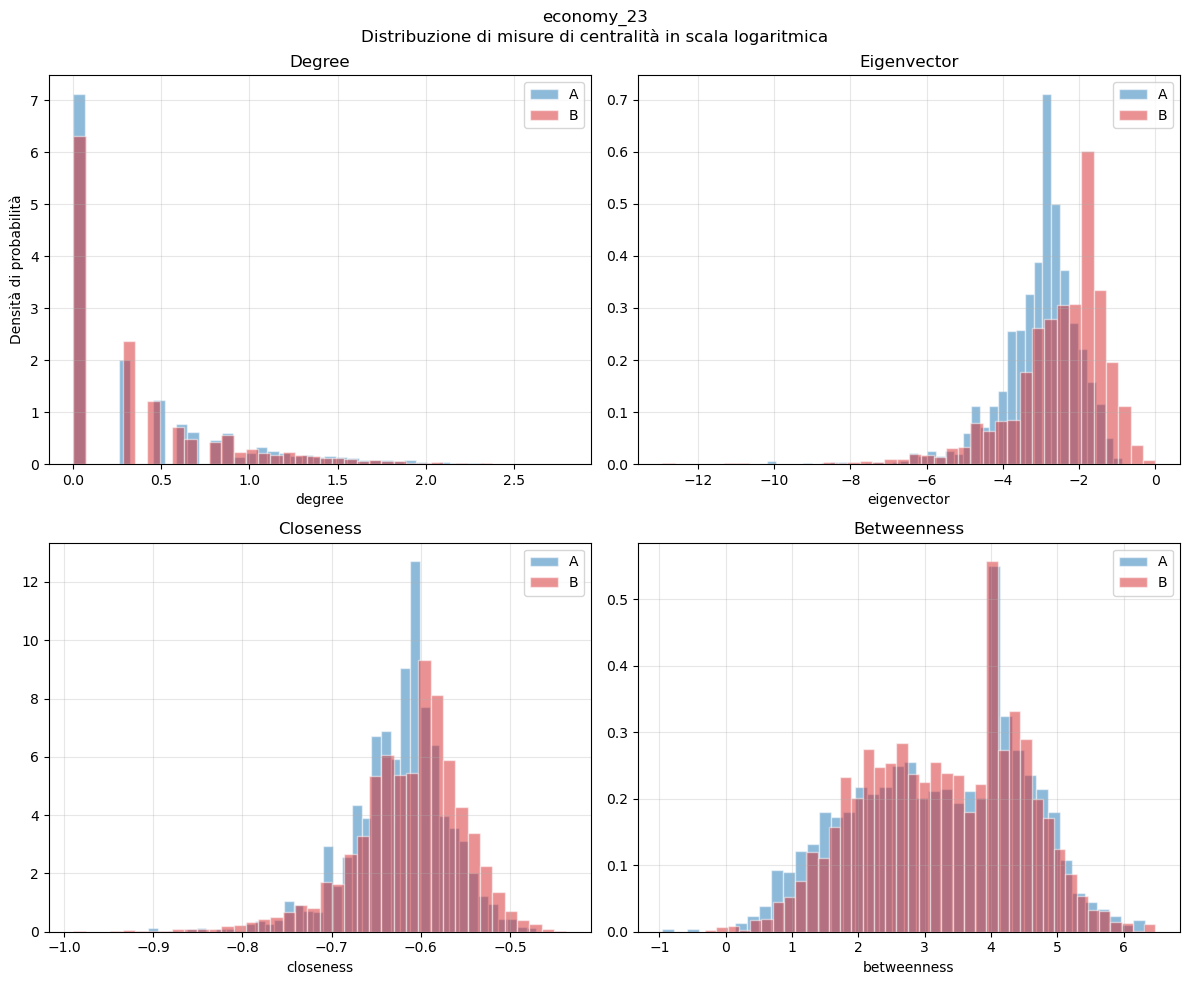

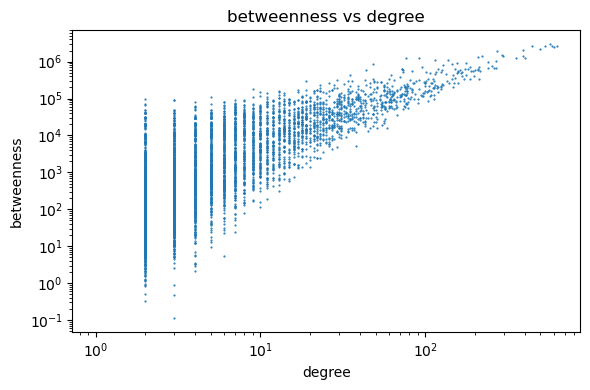

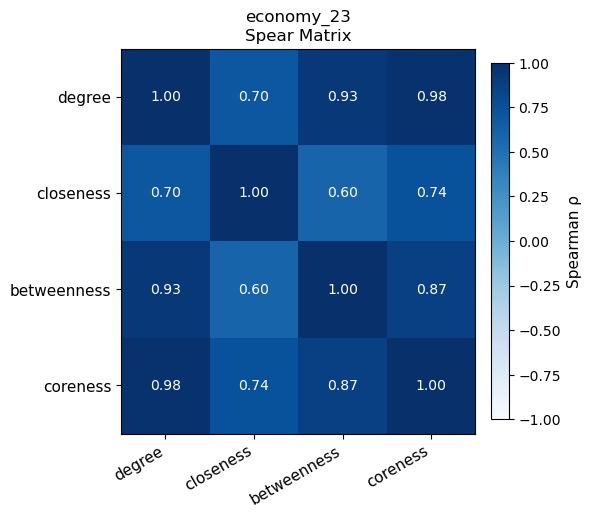

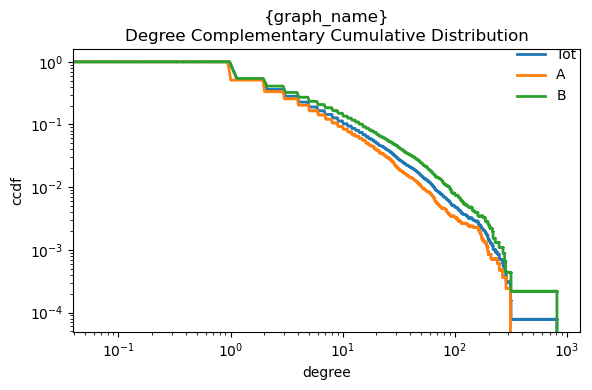

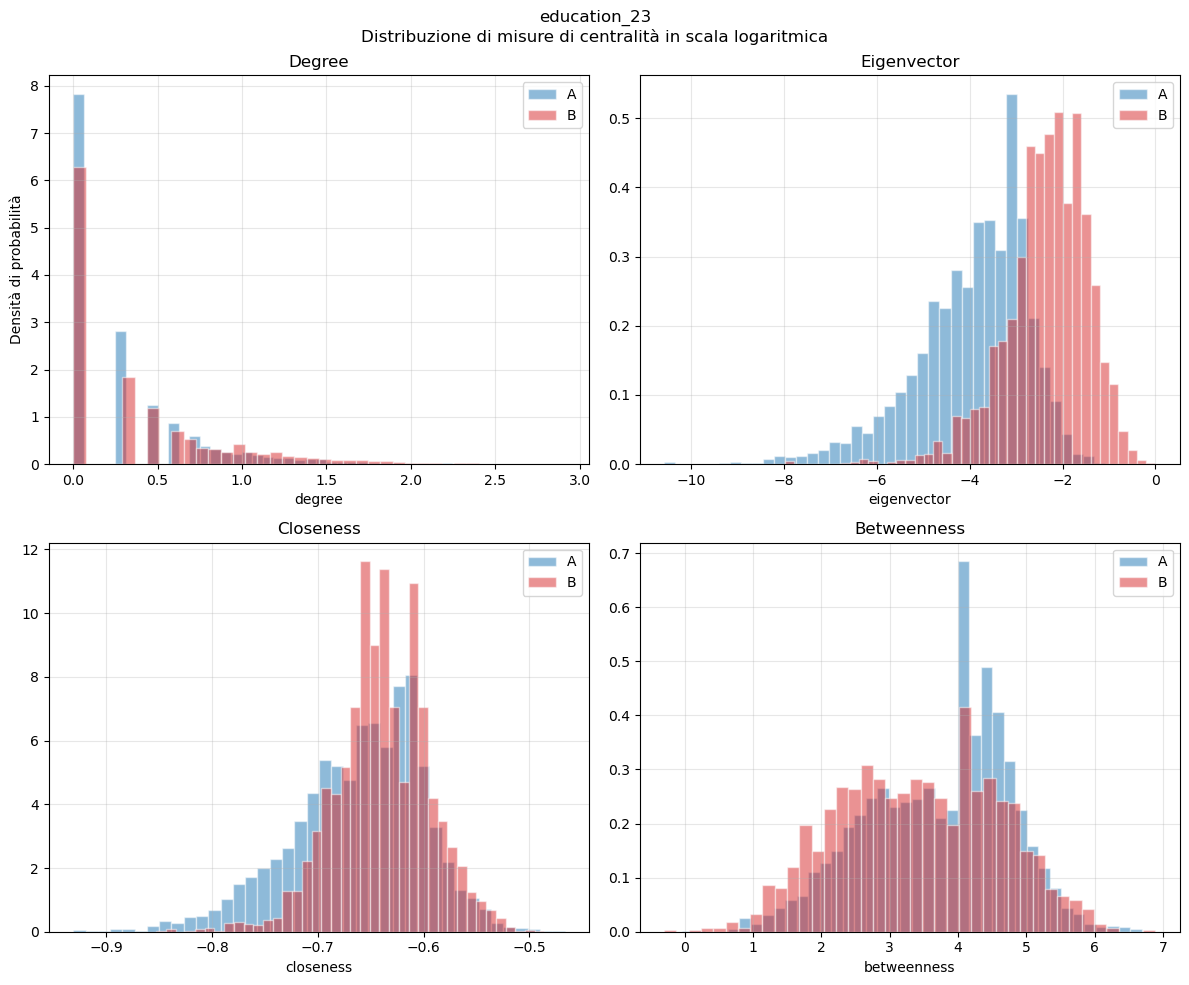

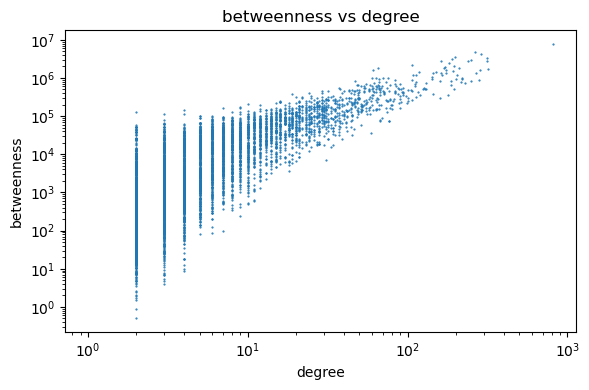

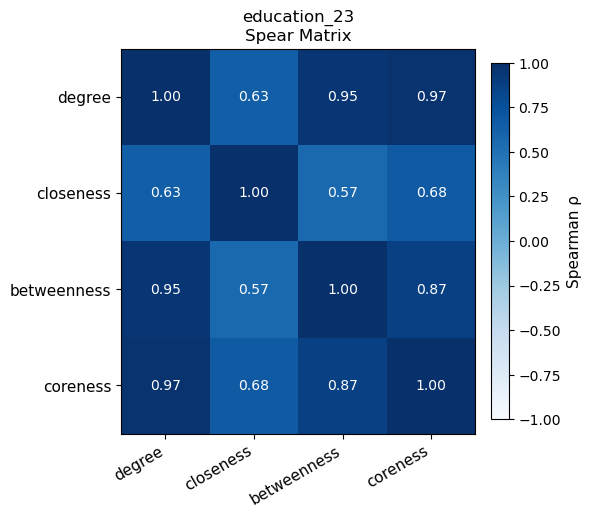

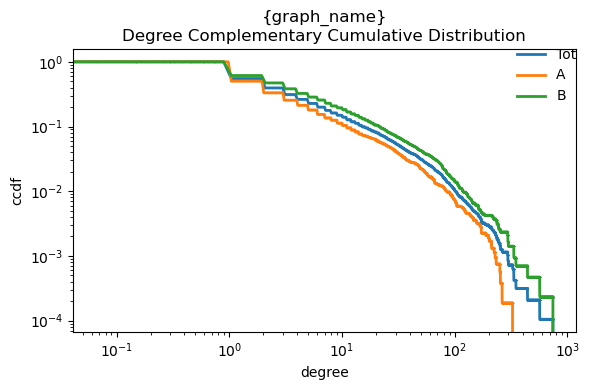

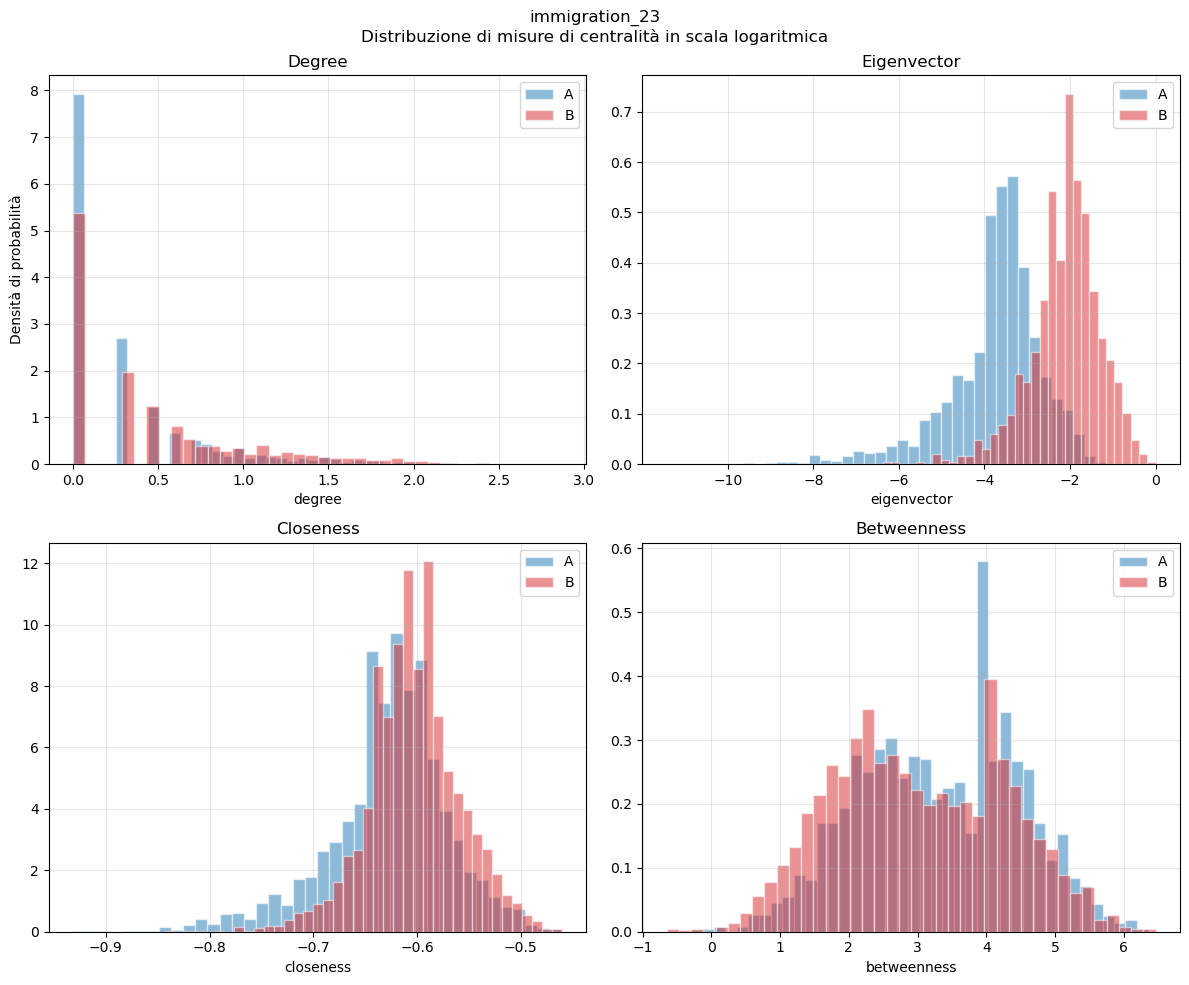

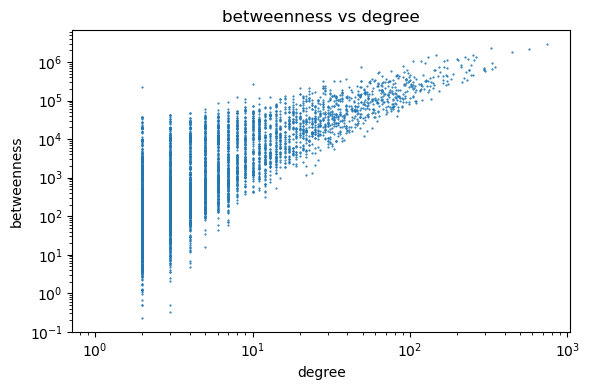

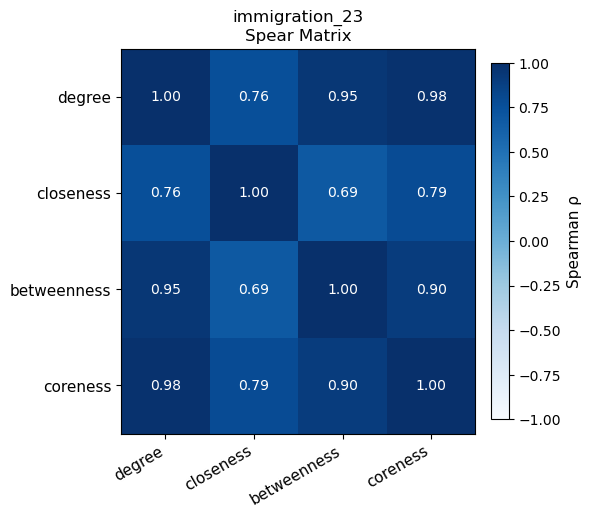

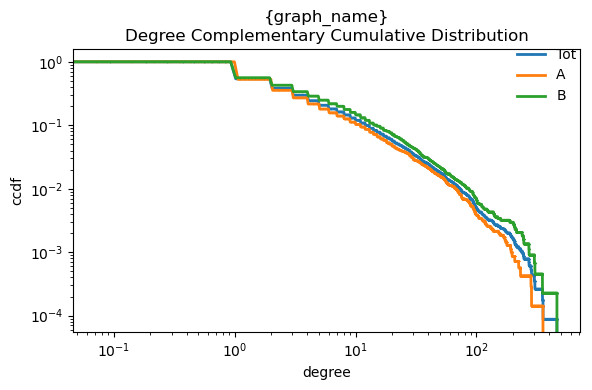

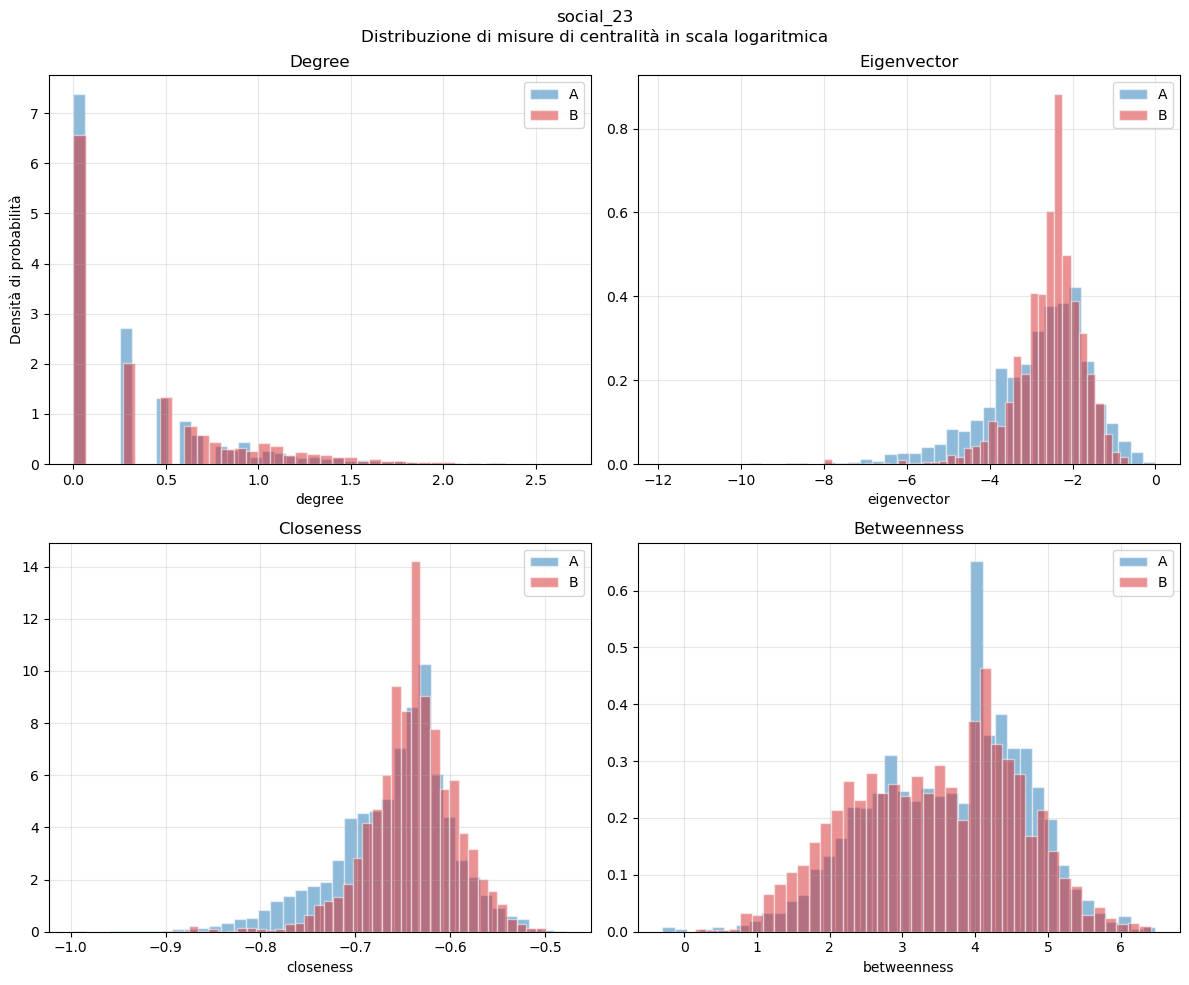

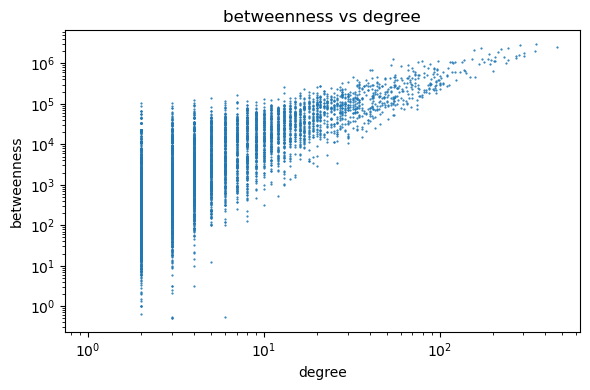

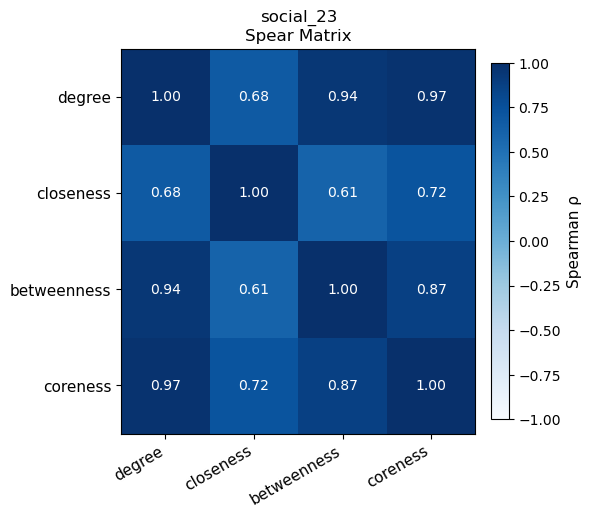

In [ ]:
PLOT_ALL_NETWORKS = True
if PLOT_ALL_NETWORKS:
    for graph_file in GRAPH_FILENAMES:
        graph_name = graph_file.removesuffix('.graphml')
        graph_file = 'Centrality_' + graph_file
        G = load_graph(DATA_DIR+graph_file)
        plot_ccdf(G, savefile=f'{VISUAL_DIR}{graph_name}_degree_ccdf.png', 
                  title=f"{graph_name}\nDegree Complementary Cumulative Distribution")
        plot_centralities(G, f'{VISUAL_DIR}{graph_name}_centralities.png', 
                          title=f'{graph_name}\nDistribuzione di misure di centralità in scala logaritmica')
        scatter_betweenness_degree(G, f'{VISUAL_DIR}{graph_name}_scatter_bet_deg.png',
                                   title=f'{graph_name}\nBetweenness vs Degree')
        plot_spearMatrix(G, f'{VISUAL_DIR}{graph_name}_spearMatrix.png',
                         title=f'{graph_name}\nSpear Matrix')

In [52]:
graph_file

'Centrality_social_23.graphml'